In [1]:
# Put import statements here
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.util.logger import Logger


In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [3]:
# Quick example of how to use the custom logger class I made
# Delete this section later
# This is just to help with keeping logs pretty
# The logger can be used from any class, after it is imported

# you can do some minor configuration of the logging in src/config.py

Logger.info("Example of how to log at info level")
Logger.debug("Example of how to log at debug level")
Logger.warning("Example of how to log at warning level")
Logger.error("Example of how to log at error level")
Logger.critical("Example of how to log at critical level")



15:47:49 [INFO    ]: Example of how to log at info level
15:47:49 [DEBUG   ]: Example of how to log at debug level
15:47:49 [WARNING ]: Example of how to log at warning level
15:47:49 [ERROR   ]: Example of how to log at error level
15:47:49 [CRITICAL]: Example of how to log at critical level


In [4]:
# Determine the project root's location, that way file paths will be more consistent
PROJECT_ROOT= Path.cwd()
DATA_DIR= PROJECT_ROOT / "data"

Logger.info(f"Project root absolute path: {PROJECT_ROOT}")

15:47:49 [INFO    ]: Project root absolute path: /home/chris/capstone/PlantQA


In [5]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / "PlantExpertVQA" / "data"
train_data_path= plant_expert_vqa_data_path / "train.csv" 
test_data_path= plant_expert_vqa_data_path / "test.csv" 
validation_data_path= plant_expert_vqa_data_path / "val.csv" 


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

15:47:51 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/home/chris/capstone/PlantQA/src/data_preprocessing/text_preprocessing.py:26: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


15:47:52 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
15:47:52 [DEBUG   ]: [load_csv] Successfully loaded /home/chris/capstone/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [6]:
# Clean and normalize the data (does not tokenize here)

# (column_name, N/A replacement val) pairs
column_fill_pairs= [
    ("answer_type", "unspecified"),
    ("question_text", ""),
    ("question_category", "unspecified"),
    ("cognitive_level", "unspecified"),
]
# text columns to normalize
columns_to_preprocess= ["question_text", "answer"]
# unwanted columns
columns_to_remove= ["dataset_source"]

# preprocess (not tokenize) the training, testing, and validation datasets

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    columns_to_preprocess,
    columns_to_remove,
    column_fill_pairs
)


In [7]:
# explore the cleaned training dataset
text_explore.explore_data(plant_expert_vqa_TRAIN, "Plant Expert VQA Training Dataset")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
15:53:56 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



15:53:56 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

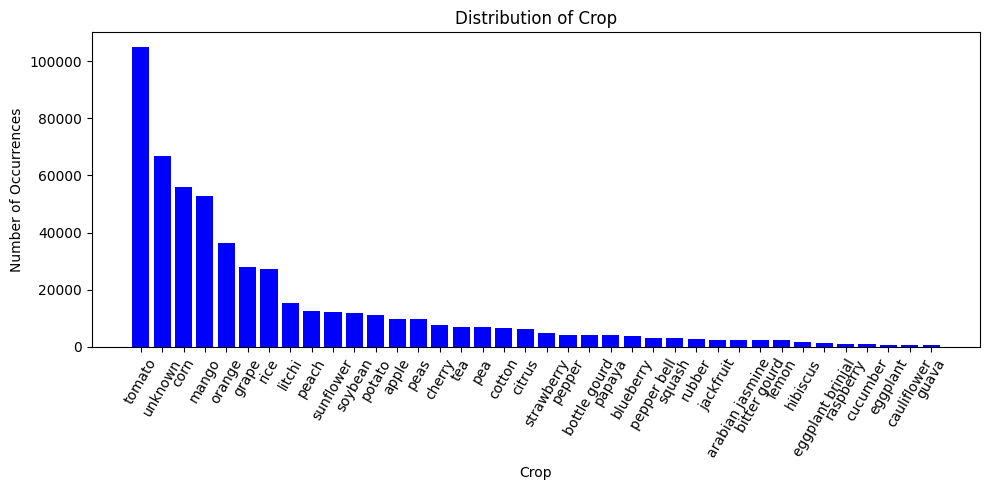

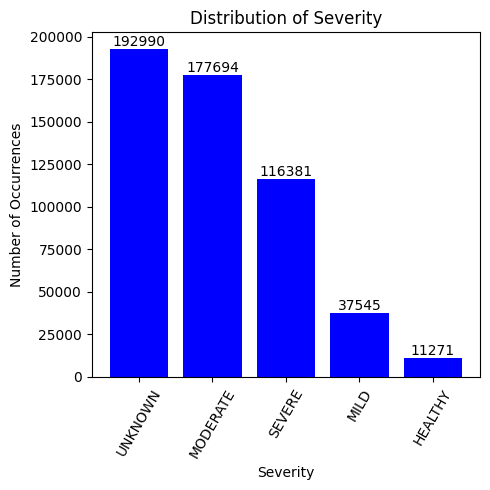

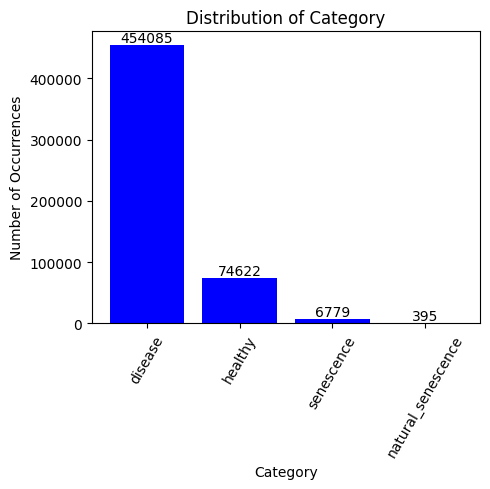

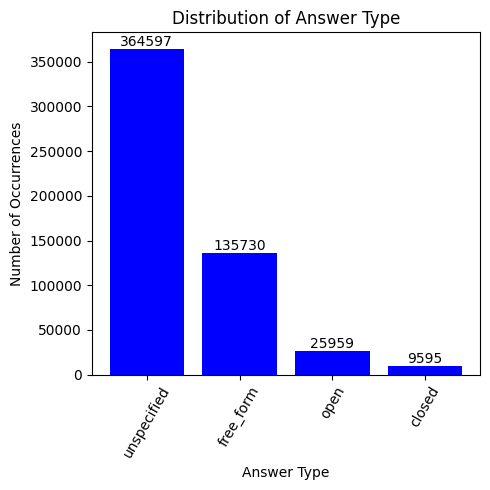

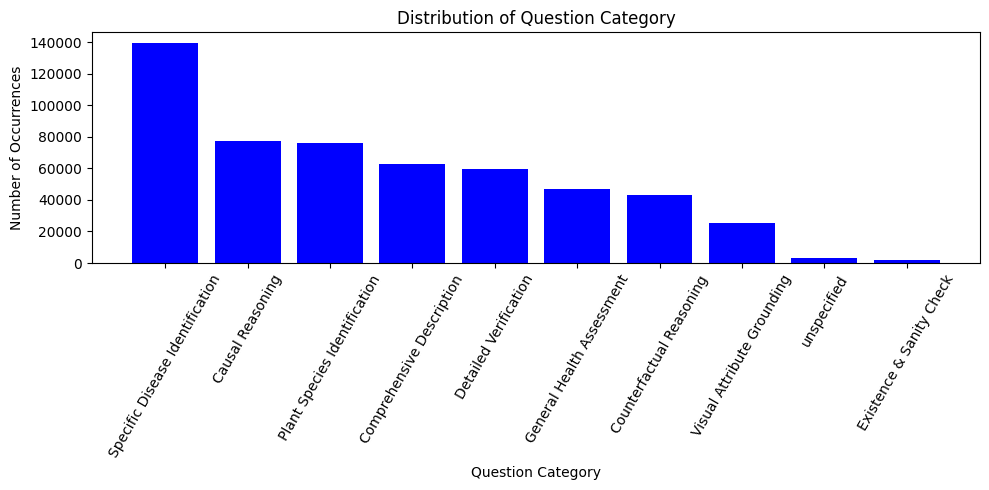

In [8]:
# make distributions of some columns, so we know how common each type is
#NOTE: we should clean/normalize the text before doing this

text_explore.make_column_distribution_graph(plant_expert_vqa_TRAIN, "crop", size=(10,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_TRAIN, "severity", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_TRAIN, "category", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_TRAIN, "answer_type", show_counts=True, size=(5,5))
text_explore.make_column_distribution_graph(plant_expert_vqa_TRAIN, "question_category", show_counts=False, size=(10,5))


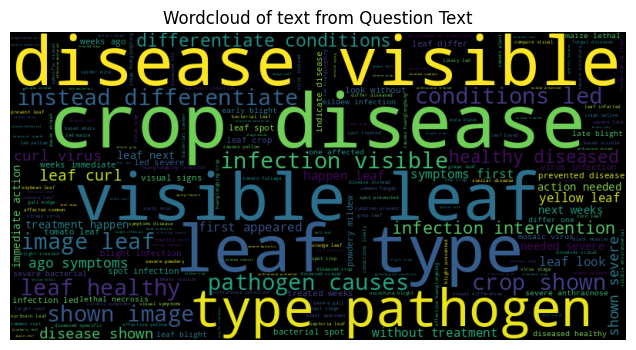

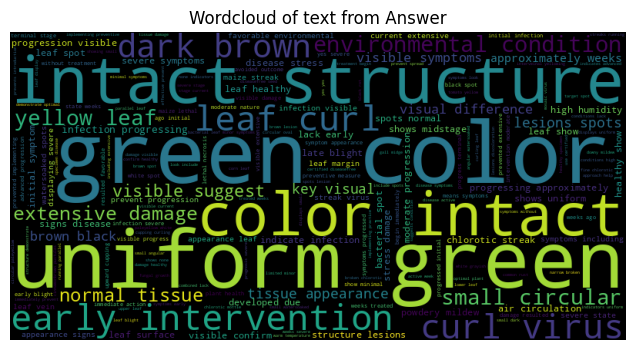

In [9]:
# make wordclouds of some of the text columns
# This helps visualize which words are the most common in teh dataset
text_explore.make_wordcloud(plant_expert_vqa_TRAIN, "question_text")
text_explore.make_wordcloud(plant_expert_vqa_TRAIN, "answer")

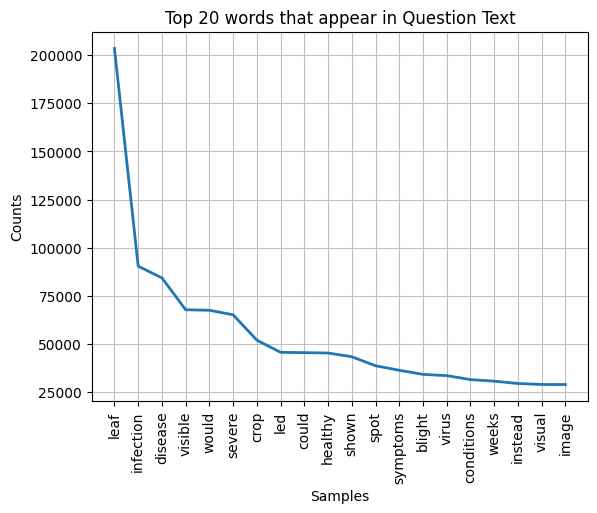

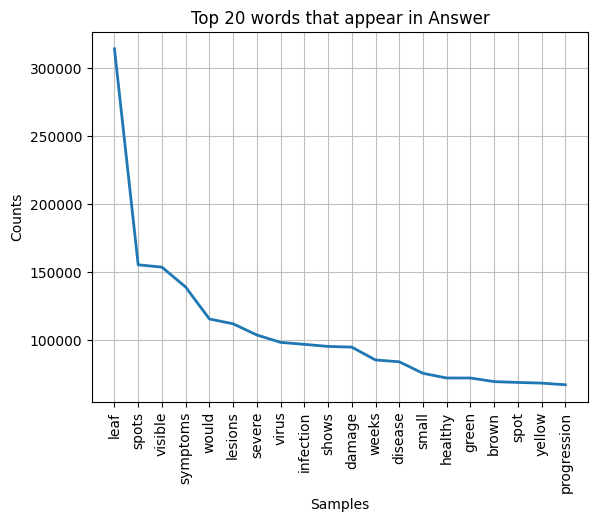

In [10]:
# make distribution of top words in the question/answer columns
#NOTE: we should clean/normalize the text before doing this
top_n_words= 20
text_explore.make_most_frequent_words_distribution(plant_expert_vqa_TRAIN, "question_text", top_n_words=top_n_words)
text_explore.make_most_frequent_words_distribution(plant_expert_vqa_TRAIN, "answer", top_n_words=top_n_words)